### **Банковский депозит**
**Бизнес-цель: Повысить эффективность маркетинговых звонков по срочным депозитам**
1. Построить портрет потенциального клиента
2. Построить предиктивную модель, которая покажет основные факторы, по которым будет проводиться обзвон.

Используется набор данных, который содержит информацию, связанную с маркетинговой кампанией банка, проводимой для продвижения подписок на срочные депозиты среди клиентов. 

Данные были собраны с помощью прямых маркетинговых усилий, в первую очередь через телефонные звонки, где были записаны различные атрибуты клиентов и детали кампании.

### Сначала проведем EDA,чтобы найти портрет клиента

In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [277]:
df = pd.read_csv('/Users/dmirtymikhalev/Desktop/project/bank.csv')

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [279]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [280]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [281]:
df['deposit'].value_counts(normalize=True)

deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64

 **Yes** составил 47%, нету сильного дисбаланса.

In [282]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

**poutcome** это результат предыдущей маркетинговой кампании

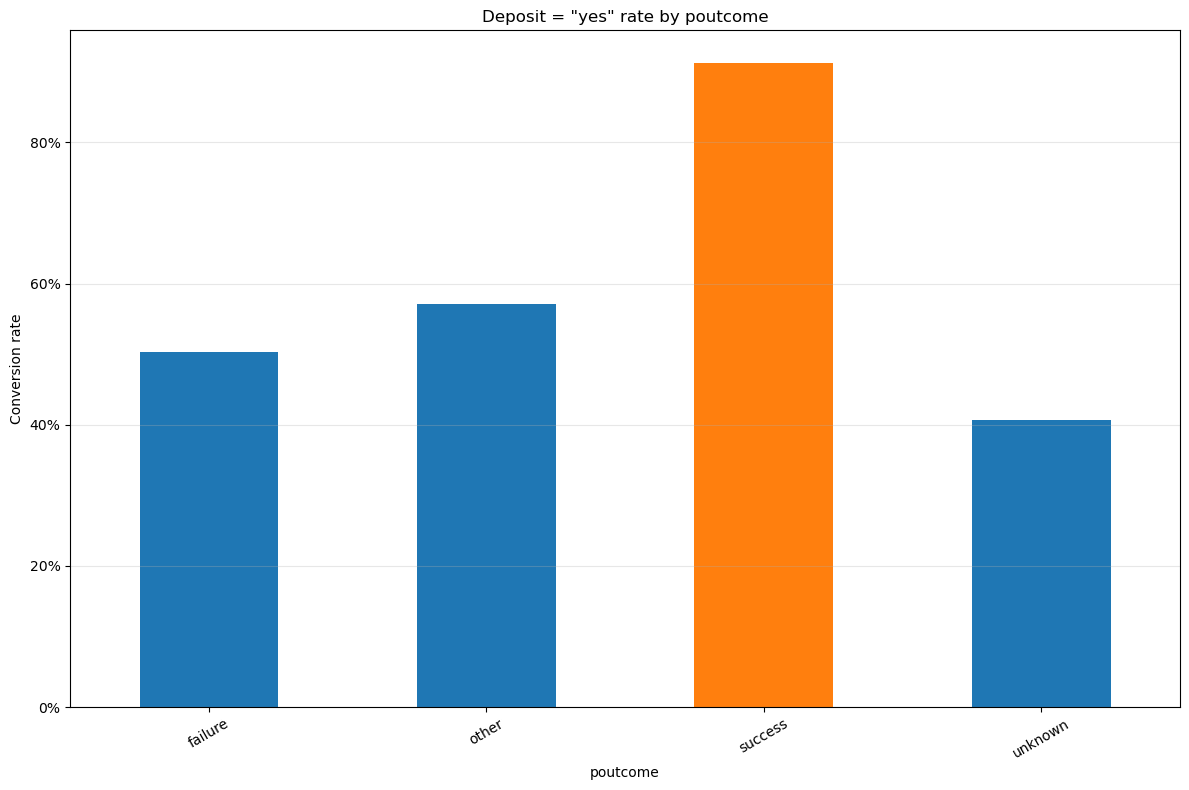

In [283]:
poutcome_rate = (
    df.groupby('poutcome')['deposit']
      .value_counts(normalize=True)
      .unstack()
)
yes_rate = poutcome_rate['yes']

plt.figure(figsize=(12, 8))

colors = ['tab:orange' if idx == 'success' else 'tab:blue' 
          for idx in yes_rate.index]

ax = yes_rate.plot(kind='bar', color=colors)

plt.xticks(rotation=30)
plt.ylabel('Conversion rate')
plt.title('Deposit = "yes" rate by poutcome')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [284]:
table = (
    df.groupby('poutcome')['deposit']
      .value_counts(normalize=True)
      .unstack()
)
table = (table * 100).round(2).astype(str) + '%'
table

deposit,no,yes
poutcome,,
failure,49.67%,50.33%
other,42.83%,57.17%
success,8.68%,91.32%
unknown,59.33%,40.67%


In [285]:
df['poutcome'].value_counts(normalize=True)

poutcome
unknown    0.745924
failure    0.110016
success    0.095951
other      0.048110
Name: proportion, dtype: float64

 **success** занимает около 10% от всей базы, и у этих 10% конверсия 91%, таких клиентов нужно обзванивать в первую очередь

 1. Клиенты, ранее успешно участвовавшие в кампании, с высокой вероятностью подпишутся снова
 2. 50% конверсии в **failure**, при провале прошлой компании, довольно странно.
 3. Основная масса клиентов — **unknown**, и у них конверсия 41%

#### *Надо проверить пункт 2*

In [286]:
counts = pd.crosstab(df['poutcome'], df['deposit'])
summary = counts.copy()
summary['total'] = summary.sum(axis=1)
summary['conv_yes_%'] = (summary.get('yes', 0) / summary['total'] * 100).round(2)
summary = summary.sort_values('conv_yes_%', ascending=False)
summary

deposit,no,yes,total,conv_yes_%
poutcome,,,,
success,93,978,1071,91.32
other,230,307,537,57.17
failure,610,618,1228,50.33
unknown,4940,3386,8326,40.67


Проверяем, не отличается ли failure по ключевым факторам

**1. По длительности звонка**

In [287]:
df.groupby('poutcome')['duration'].agg(['count','mean','median']).round(2)

,count,mean,median
poutcome,,,
failure,1228,338.46,246.5
other,537,358.43,273.0
success,1071,347.94,277.0
unknown,8326,380.91,250.0


**2. Контакты в текущей кампании**

In [288]:
df.groupby('poutcome')['campaign'].agg(['mean','median']).round(2)

,mean,median
poutcome,,
failure,1.89,1.0
other,2.22,2.0
success,1.74,1.0
unknown,2.72,2.0


**3. Контакты в прошлых кампаниях**

In [289]:
df.groupby('poutcome')['previous'].agg(['mean','median']).round(2)

,mean,median
poutcome,,
failure,3.02,2.0
other,4.16,2.0
success,3.12,2.0
unknown,0.00,0.0


**Высокая конверсия у failure:**
* не объясняется большей длительностью звонков
* не объясняется большим количеством контактов
##### Даже клиенты с прошлым неуспехом (failure) демонстрируют значительно более высокую конверсию, чем клиенты без истории взаимодействия (unknown). Это указывает на эффект “прогрева”:* **сам факт предыдущего контакта повышает вероятность открытия депозита**.

#### **pdays** 
показывает количество дней с момента предыдущего контакта, где -1 значит “не контактировали раньше”

In [290]:
df['pdays'].describe()

count    11162.000000
mean        51.330407
std        108.758282
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.750000
max        854.000000
Name: pdays, dtype: float64

In [291]:
df['pdays'].value_counts().head()

pdays
-1      8324
 92      106
 182      89
 91       84
 181      81
Name: count, dtype: int64

**~74.6%** клиентов ранее не контактировали, что почти схоже с долей 'unknown'

In [292]:
df['contacted_before'] = (df['pdays'] != -1).astype(int)

In [293]:
df.groupby('contacted_before')['deposit'].value_counts(normalize=True).round(2).unstack()

deposit,no,yes
contacted_before,,
0,0.59,0.41
1,0.33,0.67


##### Клиенты, с которыми уже проводилась маркетинговая коммуникация, демонстрируют значительно более высокую склонность к подписке.
##### Если с клиентом уже связывались раньше, вероятность подписки 67%. Если нет - 41%.

### Влияет ли давность контакта среди тех, кто контактировал ранее?

In [294]:
df[df['contacted_before'] == 1].groupby('deposit')['pdays'].mean()

deposit
no     229.924973
yes    192.521785
Name: pdays, dtype: float64

##### Помимо самого факта предыдущего контакта, важна его свежесть
##### Можно разбить на интвервалы.

In [295]:
subset = df[df['contacted_before'] == 1].copy()

subset['pdays_bin'] = pd.cut(
    subset['pdays'],
    bins=[0, 100, 300, 1000],
    labels=['0-100', '100-300', '300+']
)

subset.groupby('pdays_bin', observed=False)['deposit'].value_counts(normalize=True).unstack()

deposit,no,yes
pdays_bin,,
0-100,0.181579,0.818421
100-300,0.341498,0.658502
300+,0.473035,0.526965


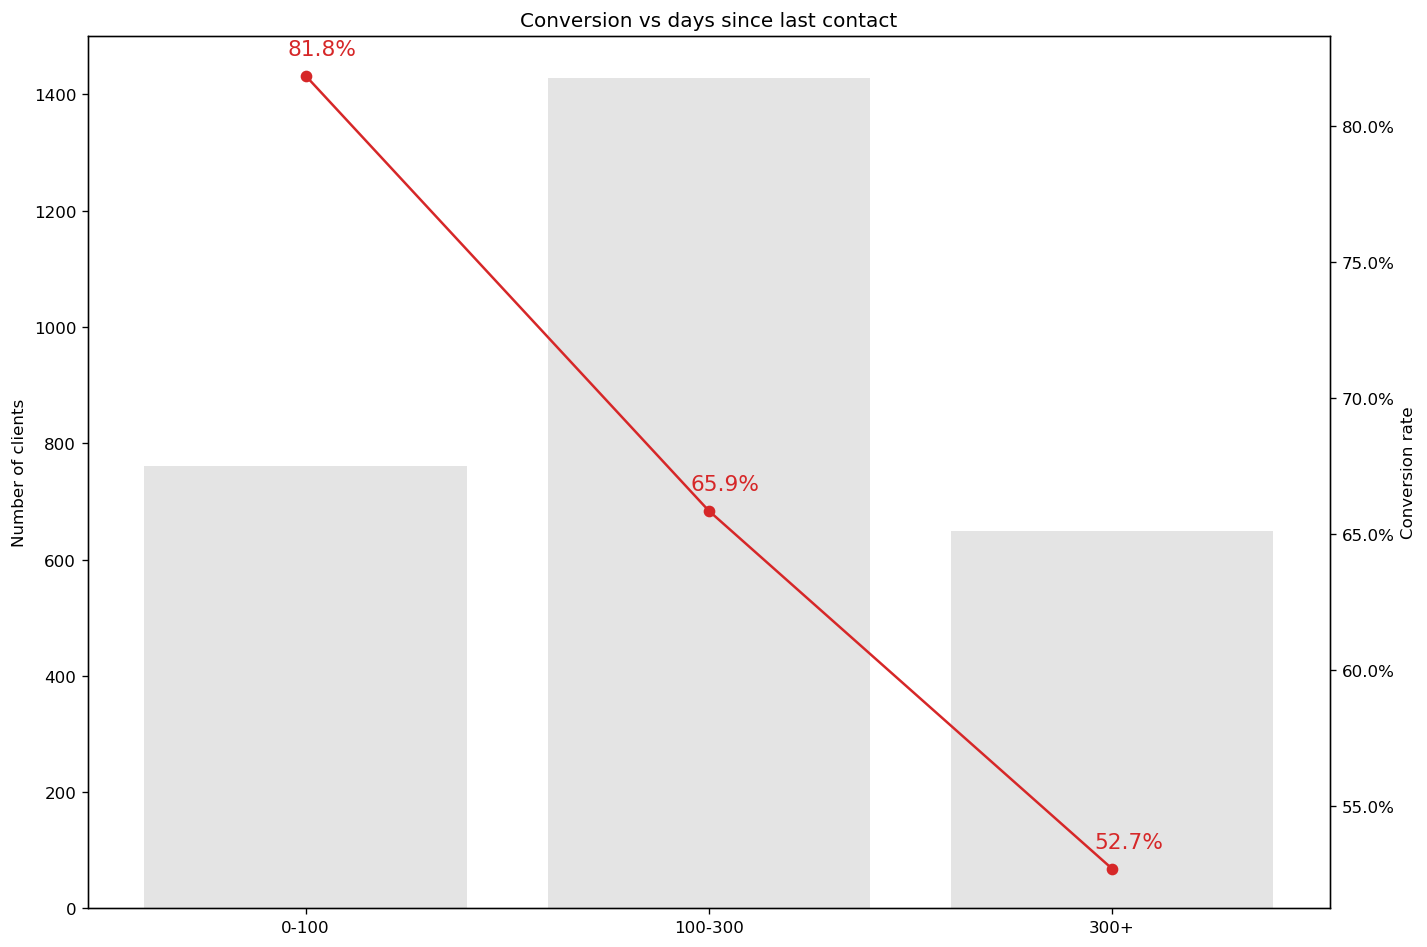

In [365]:
counts = subset['pdays_bin'].value_counts().reindex(['0-100', '100-300', '300+'])

# считаем конверсию
conv = (
    subset.groupby('pdays_bin', observed=True)['deposit']
          .value_counts(normalize=True)
          .unstack()
          .get('yes')
          .reindex(['0-100', '100-300', '300+'])
)

fig, ax1 = plt.subplots(figsize=(12, 8), dpi=120)

# столбцы
ax1.bar(counts.index, counts.values,color='lightgray', alpha=0.6)
ax1.set_ylabel('Number of clients')

# вторая ось для конверсии
ax2 = ax1.twinx()
ax2.plot(conv.index, conv.values,color='tab:red', marker='o', linewidth=1.5)
ax2.set_ylabel('Conversion rate')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# подписи процентов
for i, v in enumerate(conv.values):
    ax2.annotate(
        f'{v:.1%}',
        xy=(i, v),               
        xytext=(10, 10),           # смещение
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=13,
        color='tab:red'
    )

plt.title('Conversion vs days since last contact')
plt.tight_layout()
plt.show()

##### Чем «свежее» предыдущий контакт, тем выше вероятность открытия депозита. Эффект монотонный и выраженный, что указывает на влияние фактора давности взаимодействия.


### Теперь посмотрим на демографию

In [297]:
df.groupby('deposit')['age'].mean()

deposit
no     40.837391
yes    41.670070
Name: age, dtype: float64

In [298]:
df['age_bin'] = pd.cut(
    df['age'],
    bins = [18,30,40,50,60,100],
    labels = ['18-30','30-40','40-50','50-60','60+']
)

df.groupby('age_bin',observed=False)['deposit'].value_counts(normalize=True).round(2).unstack()

deposit,no,yes
age_bin,,
18-30,0.43,0.57
30-40,0.57,0.43
40-50,0.59,0.41
50-60,0.56,0.44
60+,0.18,0.82


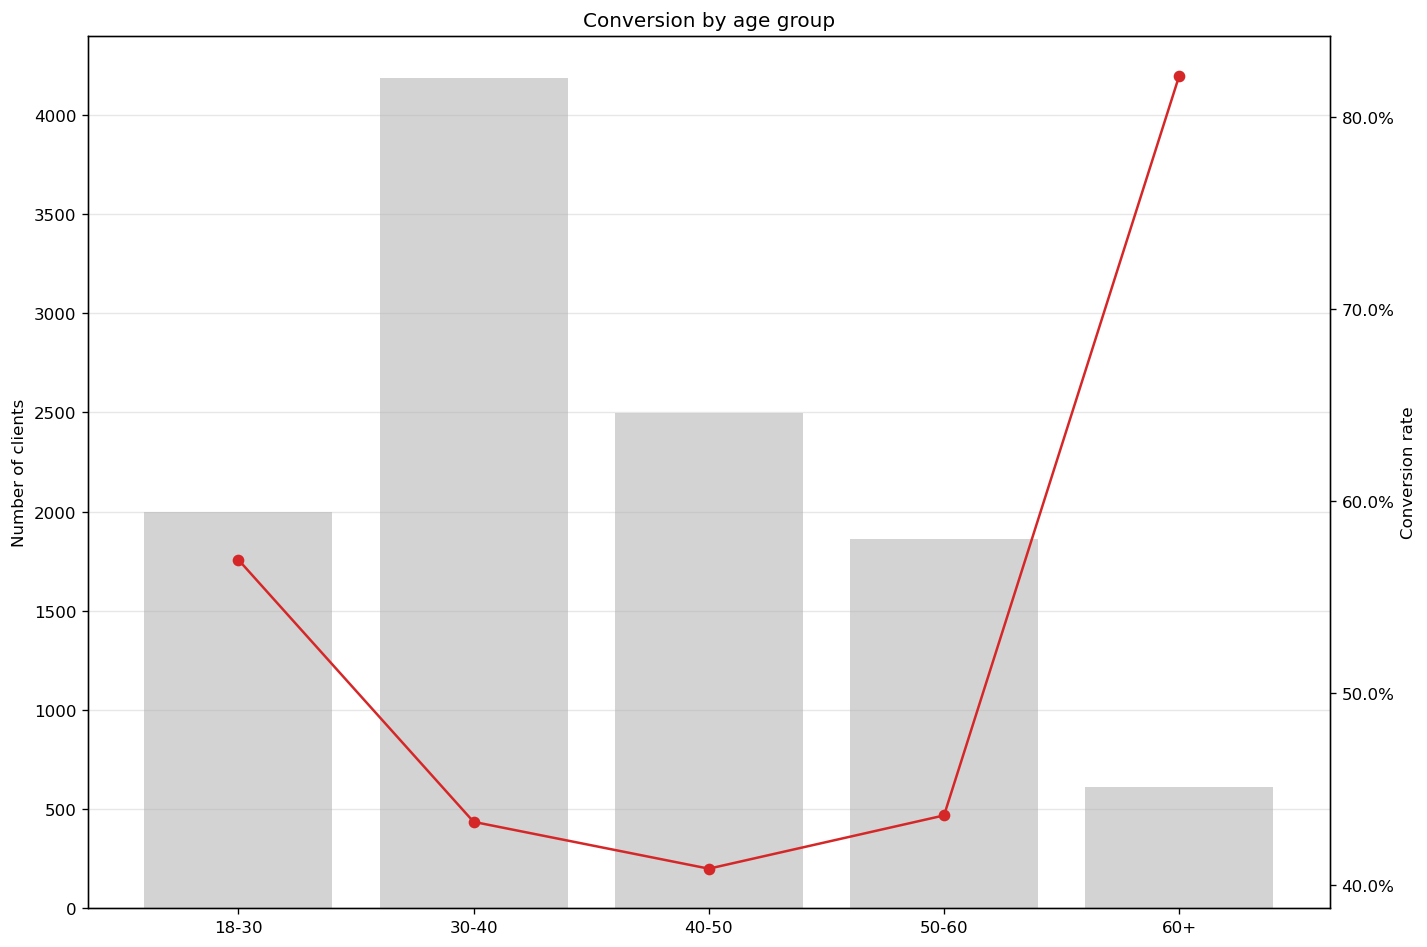

,conversion
age_bin,
18-30,56.9%
30-40,43.3%
40-50,40.8%
50-60,43.6%
60+,82.2%


In [374]:
order = ['18-30', '30-40', '40-50', '50-60', '60+']

counts_age = df['age_bin'].value_counts().reindex(order)

# конверсия
conv_age = (
    df.groupby('age_bin', observed=True)['deposit']
      .value_counts(normalize=True)
      .unstack()
      .get('yes')
      .reindex(order)
)

fig, ax1 = plt.subplots(figsize=(12, 8), dpi=120)

# столбцы
ax1.bar(counts_age.index, counts_age.values, color='lightgray')
ax1.set_ylabel('Number of clients')

# линия — конверсия
ax2 = ax1.twinx()
ax2.plot(
    conv_age.index,
    conv_age.values,
    color='tab:red',
    marker='o',
    linewidth=1.5
)
ax2.set_ylabel('Conversion rate')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title('Conversion by age group')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

table_out = (
    conv_age
        .mul(100)
        .round(1)
        .astype(str) + '%'
)

display(table_out.to_frame(name='conversion'))

In [300]:
df['age_bin'].value_counts(normalize=True).round(2)

age_bin
30-40    0.38
40-50    0.22
18-30    0.18
50-60    0.17
60+      0.05
Name: proportion, dtype: float64

In [301]:
df['age_bin'].value_counts()

age_bin
30-40    4188
40-50    2496
18-30    1999
50-60    1860
60+       611
Name: count, dtype: int64

**Сегмент 60+ занимает всего 5,5%, но имеет конверсию 82%. Также необычная ситуация в сегменте 18-30 с 57% конверсии.**
**Основная масса клиентов находится в диапазоне 30-50, на них приходится ~60% базы и конверсия 41-43%, это и будет ЦА.**

#### Надо проверить сегмент "60+"

**Длительность звонка**

In [302]:
df.groupby('age_bin',observed=True)['duration'].mean().round(1)

age_bin
18-30    377.7
30-40    374.3
40-50    365.8
50-60    368.3
60+      376.7
Name: duration, dtype: float64

**Poutcome**

In [303]:
pd.crosstab(df['age_bin'], df['poutcome'], normalize='index').round(2)

poutcome,failure,other,success,unknown
age_bin,,,,
18-30,0.09,0.06,0.11,0.75
30-40,0.13,0.05,0.08,0.74
40-50,0.10,0.04,0.08,0.77
50-60,0.10,0.04,0.09,0.77
60+,0.09,0.06,0.26,0.59


**Previous**

In [304]:
df.groupby('age_bin',observed=True)['previous'].mean().round(2)

age_bin
18-30    0.82
30-40    0.86
40-50    0.74
50-60    0.76
60+      1.31
Name: previous, dtype: float64

**Высокая конверсия сегмента 60+ объясняется не столько возрастом, сколько более «тёплой» историей взаимодействия: в этом сегменте существенно выше доля клиентов с предыдущим успешным контактом.**

**Проделаем то же самое с профессией.**

In [305]:
table = (
    df.groupby('job',observed=False)['deposit']
    .value_counts(normalize=True)
    .unstack()
)

In [306]:
counts = df['job'].value_counts()
result = table.join(counts.rename('count'))
result.sort_values(by='yes', ascending=False).round(2)

,no,yes,count
job,,,
student,0.25,0.75,360
retired,0.34,0.66,778
unemployed,0.43,0.57,357
management,0.49,0.51,2566
unknown,0.51,0.49,70
admin.,0.53,0.47,1334
self-employed,0.54,0.46,405
technician,0.54,0.46,1823
services,0.60,0.40,923


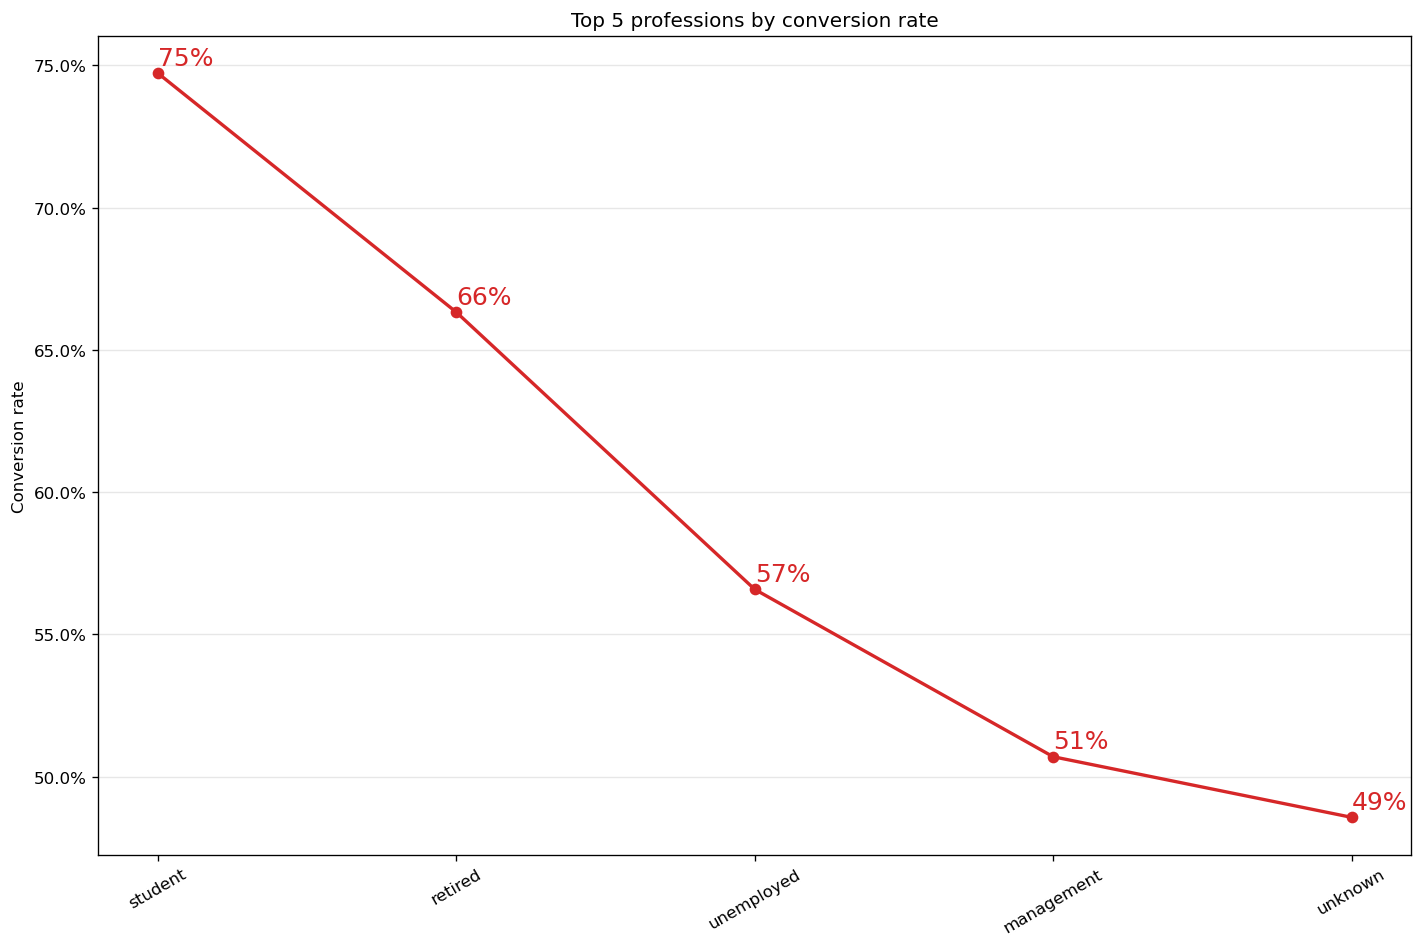

In [307]:
# топ-5 по конверсии
top5 = result.sort_values(by='yes', ascending=False).head(5)

jobs = top5.index
conv = top5['yes']

plt.figure(figsize=(12, 8), dpi=120)

plt.plot(jobs, conv, marker='o', linewidth=2, color='tab:red')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# подписи процентов
for i, v in enumerate(conv.values):
    plt.text(i, v + 0.003, f'{v:.0%}', ha='left', color='tab:red',fontsize=15)

plt.title('Top 5 professions by conversion rate')
plt.ylabel('Conversion rate')
plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [308]:
df['job'].value_counts(normalize=True).sort_values(ascending=False).round(2)

job
management       0.23
blue-collar      0.17
technician       0.16
admin.           0.12
services         0.08
retired          0.07
self-employed    0.04
student          0.03
unemployed       0.03
entrepreneur     0.03
housemaid        0.02
unknown          0.01
Name: proportion, dtype: float64

##### **Management** — стратегически важный сегмент. 50% конверсии в самом большом сегменте.
**Высокая склонность к подписке у:**
* студентов
* пенсионеров
* безработных
* управленцев

**Также важно отметить, что 'retired' и '60+' это один и тот же сегмент**

 **Теперь проверим финансовые признаки:**
* housing (ипотека)
* loan (потребительский кредит)

In [309]:
df.groupby('housing')['deposit'].value_counts(normalize=True).unstack()

deposit,no,yes
housing,,
no,0.429689,0.570311
yes,0.633592,0.366408


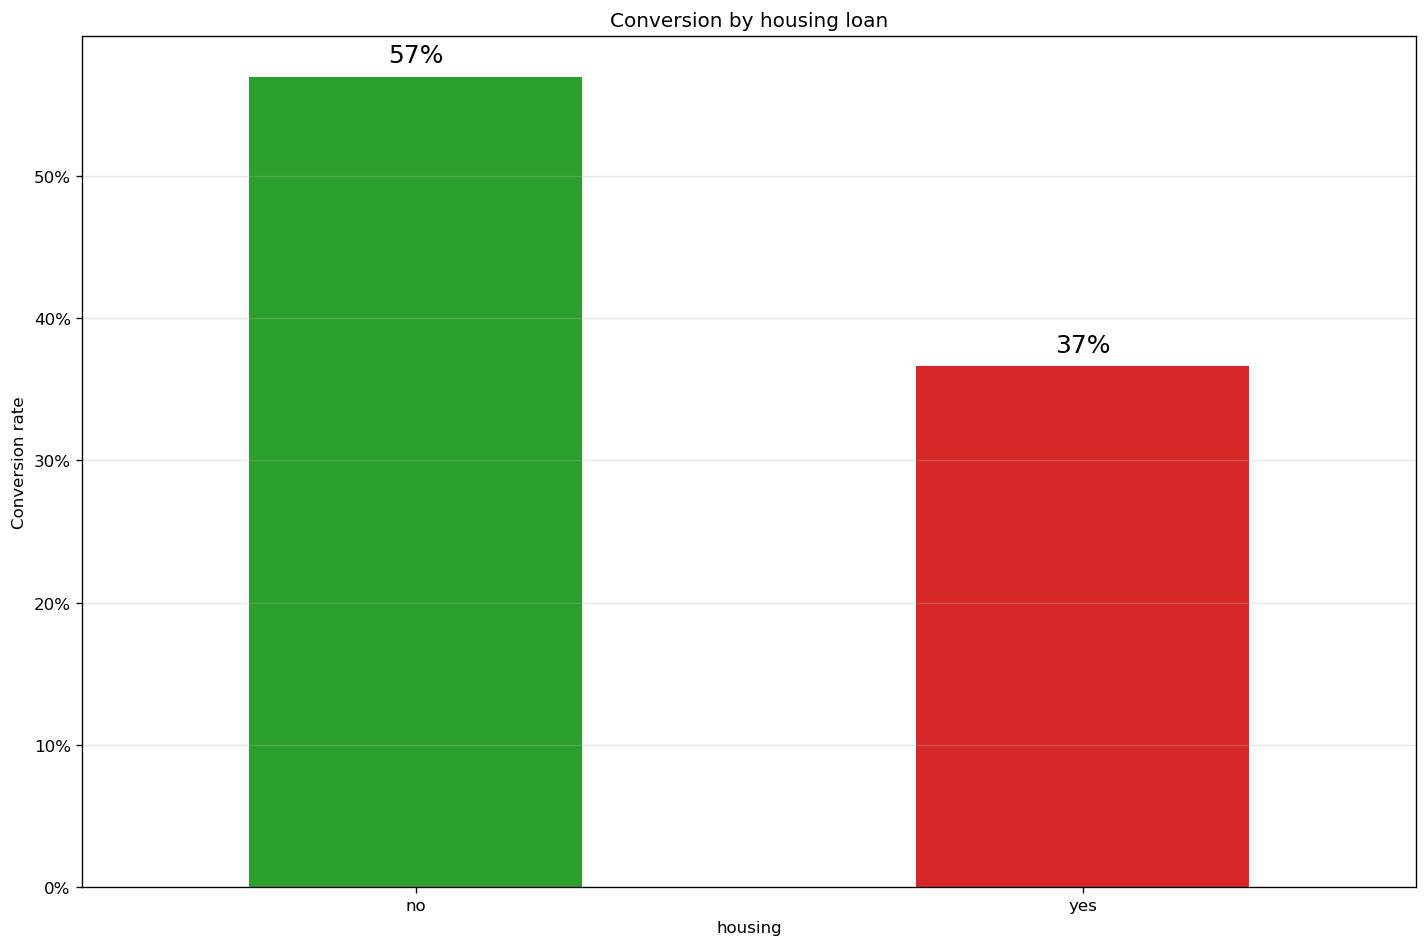

In [310]:
conv_housing = (
    df.groupby('housing', observed=True)['deposit']
      .value_counts(normalize=True)
      .unstack()
      .get('yes')
)

plt.figure(figsize=(12, 8), dpi=120)

ax = conv_housing.plot(kind='bar', color=['tab:green', 'tab:red'])

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(conv_housing.values):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center',fontsize=15)

plt.title('Conversion by housing loan')
plt.ylabel('Conversion rate')
plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [311]:
df.groupby('loan')['deposit'].value_counts(normalize=True).unstack()

deposit,no,yes
loan,,
no,0.504741,0.495259
yes,0.668493,0.331507


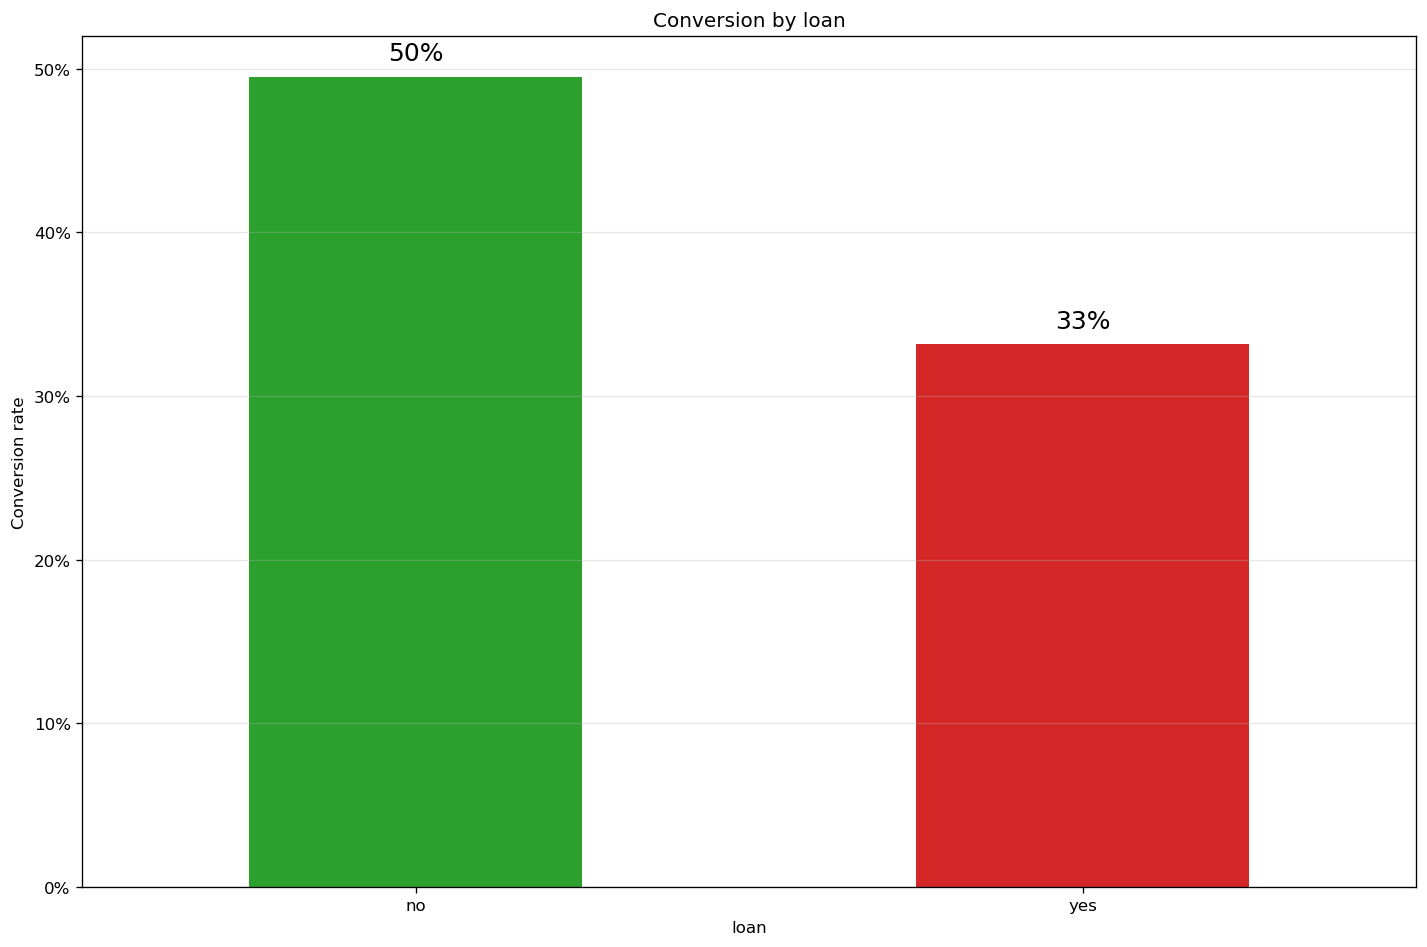

In [312]:
conv_loan = (
    df.groupby('loan', observed=True)['deposit']
      .value_counts(normalize=True)
      .unstack()
      .get('yes')
)

plt.figure(figsize=(12, 8), dpi=120)

ax = conv_loan.plot(kind='bar', color=['tab:green', 'tab:red'])

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, v in enumerate(conv_loan.values):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=15)

plt.title('Conversion by loan')
plt.ylabel('Conversion rate')
plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Наличие действующих кредитных обязательств существенно снижает вероятность открытия депозита. Клиенты без ипотеки и потребительского кредита демонстрируют значительно более высокую конверсию.**

### Теперь начнем подготовку данных для модели

In [313]:
df_model = df.drop(columns=['duration'])

In [314]:
df_model['pdays_bin'] = np.where(
    df['pdays'] == -1,
    'no_contact',
    pd.cut(
        df['pdays'],
        bins=[0, 100, 300, 1000],
        labels=['0-100', '100-300', '300+']
    )
)

In [315]:
df_model = df_model.drop(columns=['pdays'])

In [316]:
df_model[['contacted_before','age_bin','pdays_bin']].isna().mean()
df_model['pdays_bin'].value_counts(dropna=False)
df_model['age_bin'].value_counts(dropna=False)
df_model = df_model.dropna(subset=['age_bin'])

#### Теперь нет NaN

In [317]:
df_model = df_model.copy()
df_model['deposit'] = df.loc[df_model.index, 'deposit']

In [318]:
s = df_model['deposit'].astype(str).str.strip().str.lower()
df_model.loc[:, 'deposit'] = s.map({'no': 0, 'yes': 1})

#### Сделали таргет 0/1

### Теперь к модели логистической регрессии

In [319]:
X = df_model.drop(columns=['deposit'])
y = df_model['deposit']

In [320]:
X.shape, y.shape

((11154, 17), (11154,))

In [321]:
X_encoded = pd.get_dummies(X,drop_first=True)

In [322]:
X_encoded.shape

(11154, 48)

In [323]:
 X_encoded.head()

,age,balance,day,campaign,previous,contacted_before,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,poutcome_other,poutcome_success,poutcome_unknown,age_bin_30-40,age_bin_40-50,age_bin_50-60,age_bin_60+,pdays_bin_100-300,pdays_bin_300+,pdays_bin_no_contact
0,59,2343,5,1,0,0,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
1,56,45,5,1,0,0,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
2,41,1270,5,1,0,0,False,False,False,False,...,False,False,True,False,True,False,False,False,False,True
3,55,2476,5,1,0,0,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True
4,54,184,5,2,0,0,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True


In [324]:
y = df_model['deposit'].astype(int)

In [325]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [326]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8923, 48), (2231, 48), (8923,), (2231,))

In [327]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("lr", LogisticRegression(max_iter=10000))
])

In [328]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('lr', LogisticRegression(max_iter=10000))])

In [329]:
pipe.named_steps["lr"].coef_

array([[-0.1940555 ,  0.09517173, -0.02972077, -0.21047223,  0.01760835,
         0.60933782, -0.02193038, -0.02932459, -0.03662894, -0.06258069,
         0.03276987, -0.04335785, -0.02280813,  0.08153864, -0.01328601,
         0.04208149, -0.0309291 , -0.1072598 , -0.01925851,  0.06864515,
         0.16397832,  0.03044182, -0.01269154, -0.19256309, -0.1463423 ,
        -0.08134599, -0.50603438, -0.24819669,  0.10491193, -0.13550591,
        -0.19167163, -0.21727734,  0.04874052,  0.1809854 , -0.20578779,
        -0.24137961,  0.13512063,  0.07948202,  0.04612102,  0.58347839,
         0.2576515 , -0.1131603 , -0.03903307,  0.02834159,  0.28424065,
        -0.12122127, -0.10154829,  0.23735323]])

#### Обучение прошло успешно
#### Но на сколько?

In [330]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

In [331]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Confusion matrix:
[[968 207]
 [460 596]]

Classification report:
              precision    recall  f1-score   support

           0      0.678     0.824     0.744      1175
           1      0.742     0.564     0.641      1056

    accuracy                          0.701      2231
   macro avg      0.710     0.694     0.692      2231
weighted avg      0.708     0.701     0.695      2231

ROC-AUC: 0.7626208897485492


**1. Confusion_matrix: 
[[TN  FP]
[FN  TP]]**

* True Negative — правильно сказали “не подпишется”
* False Positive — сказали “подпишется”, но не подписался
* **False Negative** — сказали “не подпишется”, но он подписался
* True Positive — правильно нашли подписавшегося

Модель правильно нашла 596 клиентов, которые реально подписались. 460 клиентов подписались, но модель сказала “не подпишется”

**2. Recall = TP / (TP + FN)** Из всех подписавшихся, сколько мы нашли

**3. Precision = TP / (TP + FP)** Из всех, кому мы поверили, сколько реально подписались

### Сейчас модель осторожная, видно по recall 1, она хорошо отсеивает неподписавшихся (recall 0),но плохо находит подписавшихся (recall 1)
* Важнее не упустить потенциальных клиентов
* Значит нам нужно уменьшать FN
* А это значит — увеличивать Recall

In [332]:
threshold = 0.4
y_pred_04 = (y_proba >= threshold).astype(int)

print("Confusion matrix (0.4):")
print(confusion_matrix(y_test, y_pred_04))

print("\nClassification report (0.4):")
print(classification_report(y_test, y_pred_04, digits=3))

Confusion matrix (0.4):
[[735 440]
 [277 779]]

Classification report (0.4):
              precision    recall  f1-score   support

           0      0.726     0.626     0.672      1175
           1      0.639     0.738     0.685      1056

    accuracy                          0.679      2231
   macro avg      0.683     0.682     0.678      2231
weighted avg      0.685     0.679     0.678      2231



### Мы снизили порог threshold, сделав его 0.4, тем самым **увеличи Recall с 56% до ~74%**
#### А также **уменьшился FN**. Мы перестали упускать:
* 460 - 277 = 183 клиента
#### Это 183 потенциальные сделки, которые раньше терялись

### **При пороге 0.4:**
	• Мы нашли на 183 больше клиентов
	• Но сделали на 233 больше лишних звонков
#### В контексте нашей задачи это успех

### Теперь попробуем снизить порог до 0.3 и посмотреть что будет

In [333]:
threshold = 0.3
y_pred_03 = (y_proba >= threshold).astype(int)

print("Confusion matrix (0.3):")
print(confusion_matrix(y_test, y_pred_03))

print("\nClassification report (0.3):")
print(classification_report(y_test, y_pred_03, digits=3))

Confusion matrix (0.3):
[[450 725]
 [134 922]]

Classification report (0.3):
              precision    recall  f1-score   support

           0      0.771     0.383     0.512      1175
           1      0.560     0.873     0.682      1056

    accuracy                          0.615      2231
   macro avg      0.665     0.628     0.597      2231
weighted avg      0.671     0.615     0.592      2231



### Теперь модель упускает всего 134 человека, вместо 460 при пороге 0.5 ==> +326 потенциальных сделок
#### Но соответсвенно вырос FP до 725 (с 207), что достаточно сильно, но все равно совершить 725 звонок дешевле, чем упустить 326 потенциальных сделок

### Теперь посчитаем прибыль при каждом пороге.
##### **!!Cost_per_call = $3 - предположение.!!**

##### **!!Profit_per_deposit = $100 - предположение.!!**

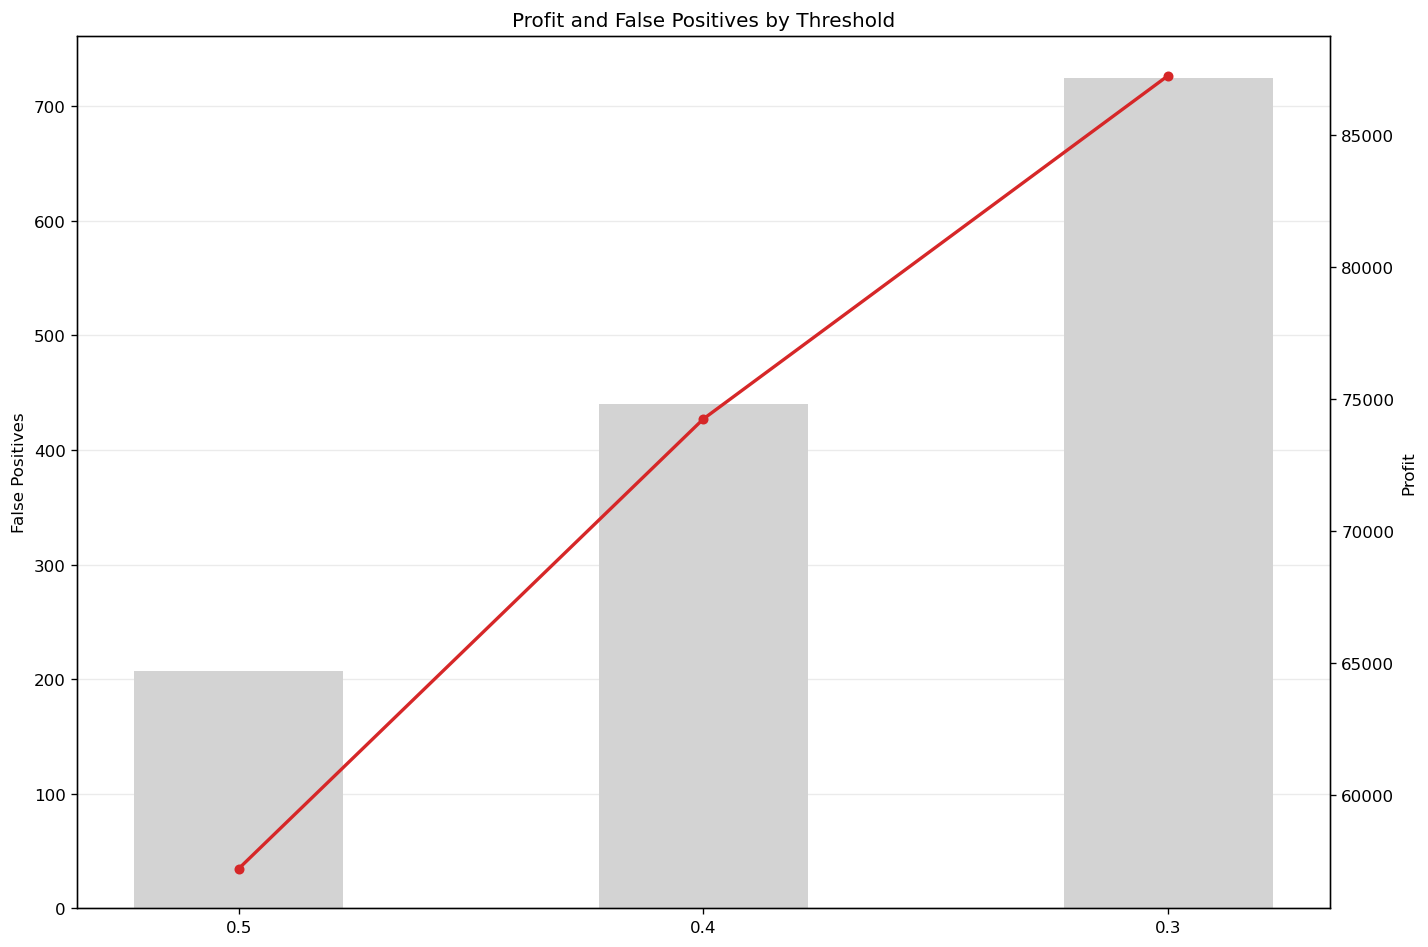

,threshold,profit
0,0.5,57191
1,0.4,74243
2,0.3,87259


In [334]:
profit_per_deposit = 100
cost_per_call = 3
thresholds = [0.5, 0.4, 0.3]

profits, fps = [], []

for thr in thresholds:
    y_pred = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    profits.append(tp * profit_per_deposit - (tp + fp) * cost_per_call)
    fps.append(fp)

res = pd.DataFrame({"threshold": thresholds, "profit": profits, "fp": fps})

# чтобы по оси X были ровные "категории", а не реальные числа
x = np.arange(len(res))
labels = [str(t) for t in res["threshold"]]

fig, ax1 = plt.subplots(figsize=(12, 8), dpi=120)

# FP столбцы
bars = ax1.bar(x, res["fp"], width=0.45, color="lightgray")
ax1.set_ylabel("False Positives")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.grid(axis="y", alpha=0.25)
ax1.set_axisbelow(True)

# Profit
ax2 = ax1.twinx()
ax2.plot(x, res["profit"], color="tab:red", marker="o", linewidth=2, markersize=5)
ax2.set_ylabel("Profit")

plt.title("Profit and False Positives by Threshold")
plt.tight_layout()
plt.show()

display(res[["threshold", "profit"]])

### Видно, что при снижении порога прибыль стремительно растет. Значит можно оставить значение 0.3

### Теперь построим RandomForest модель и сравним её с логистической.

In [335]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,      # сколько деревьев (больше → стабильнее, но дольше)
    random_state=42,
    n_jobs=-1,             # использовать все ядра
    min_samples_leaf=5     # чтобы дерево не делало слишком мелкие листья (меньше переобучение)
)

rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [336]:
rf_cls = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, rf_cls))

print("Classification report:")
print(classification_report(y_test, rf_cls, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Confusion matrix:
[[985 190]
 [405 651]]
Classification report:
              precision    recall  f1-score   support

           0      0.709     0.838     0.768      1175
           1      0.774     0.616     0.686      1056

    accuracy                          0.733      2231
   macro avg      0.741     0.727     0.727      2231
weighted avg      0.740     0.733     0.729      2231

ROC-AUC: 0.7856399097356543


### Посмотрим сразу на трех порогах:

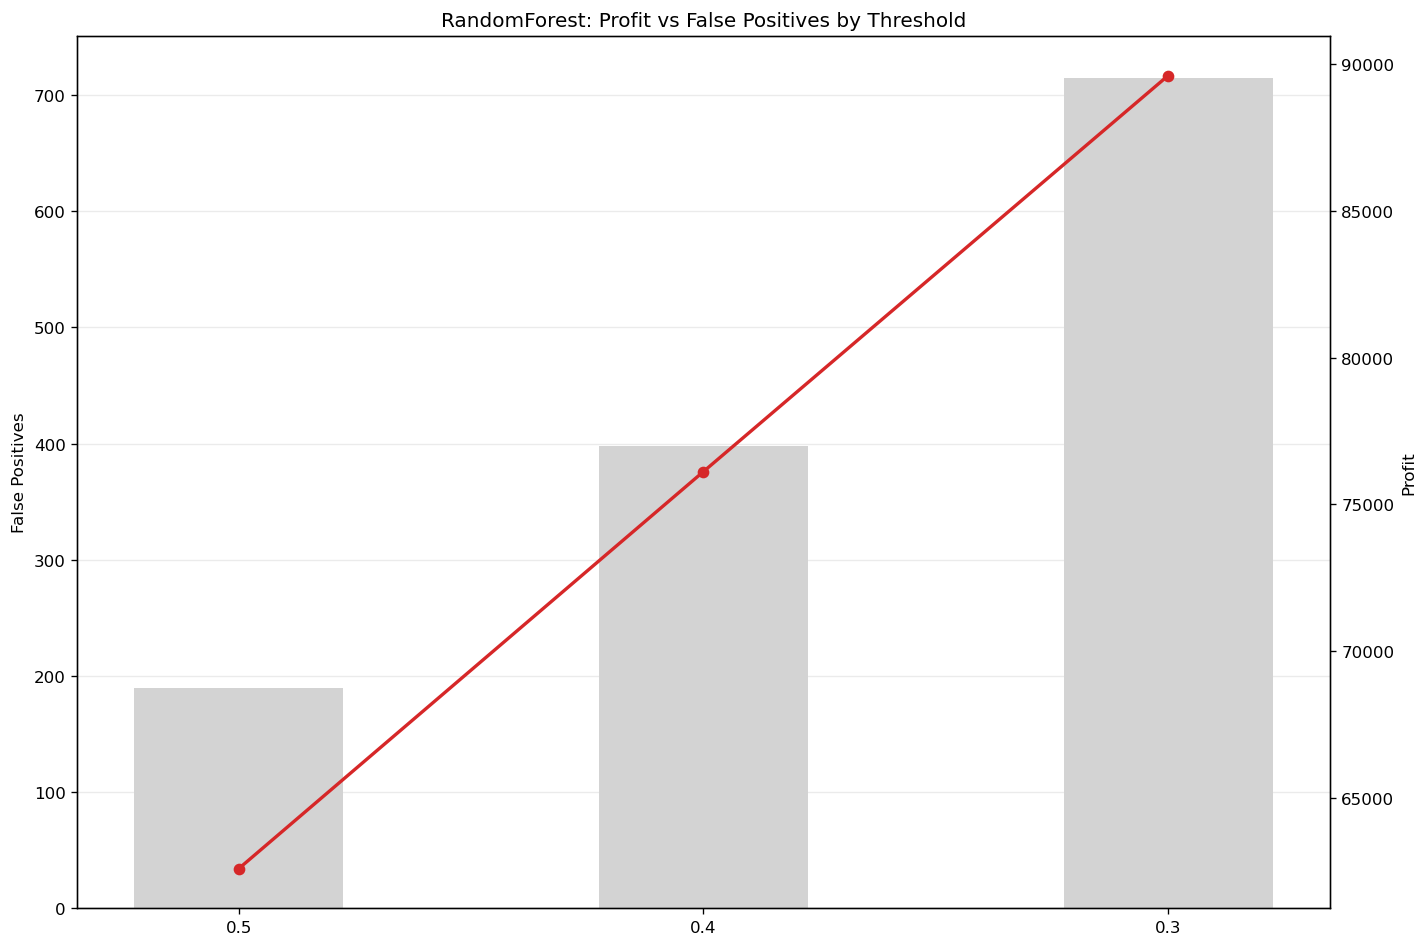

,threshold,profit
0,0.5,62577
1,0.4,76115
2,0.3,89617


In [337]:
profit_per_deposit = 100
cost_per_call = 3
cuts = [0.5, 0.4, 0.3]

profits, fps = [], []

for cut in cuts:
    rf_decision = (rf_prob >= cut).astype(int)
    tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_test, rf_decision).ravel()

    profit = tp_rf * profit_per_deposit - (tp_rf + fp_rf) * cost_per_call
    profits.append(profit)
    fps.append(fp_rf)

res_rf = pd.DataFrame({
    "threshold": cuts,
    "profit": profits,
    "fp": fps
})

# позиции X как категории
x = np.arange(len(res_rf))
labels = [str(t) for t in res_rf["threshold"]]

fig, ax1 = plt.subplots(figsize=(12, 8), dpi=120)

# FP
bars = ax1.bar(x, res_rf["fp"], width=0.45, color="lightgray",)
ax1.set_ylabel("False Positives")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.grid(axis="y", alpha=0.25)
ax1.set_axisbelow(True)

# Profit
ax2 = ax1.twinx()
ax2.plot(x, res_rf["profit"], color="tab:red", marker="o", linewidth=2)
ax2.set_ylabel("Profit")

plt.title("RandomForest: Profit vs False Positives by Threshold")
plt.tight_layout()
plt.show()

display(res_rf[["threshold", "profit"]])

### Сделаем Feature Importance, чтобы оценить,какие признаки больше всего помогают разделять классы

In [338]:
importances = rf.feature_importances_
feat_names = X_train.columns

imp = pd.DataFrame({"feature": feat_names, "importance": importances})
imp = imp.sort_values("importance", ascending=False)

print(imp.head(15))

                 feature  importance
1                balance    0.109302
0                    age    0.094969
2                    day    0.091001
39      poutcome_success    0.083120
26       contact_unknown    0.078988
23           housing_yes    0.054103
3               campaign    0.046992
4               previous    0.029350
34             month_may    0.026526
5       contacted_before    0.024631
47  pdays_bin_no_contact    0.024055
24              loan_yes    0.019655
40      poutcome_unknown    0.018440
27             month_aug    0.017388
44           age_bin_60+    0.017340


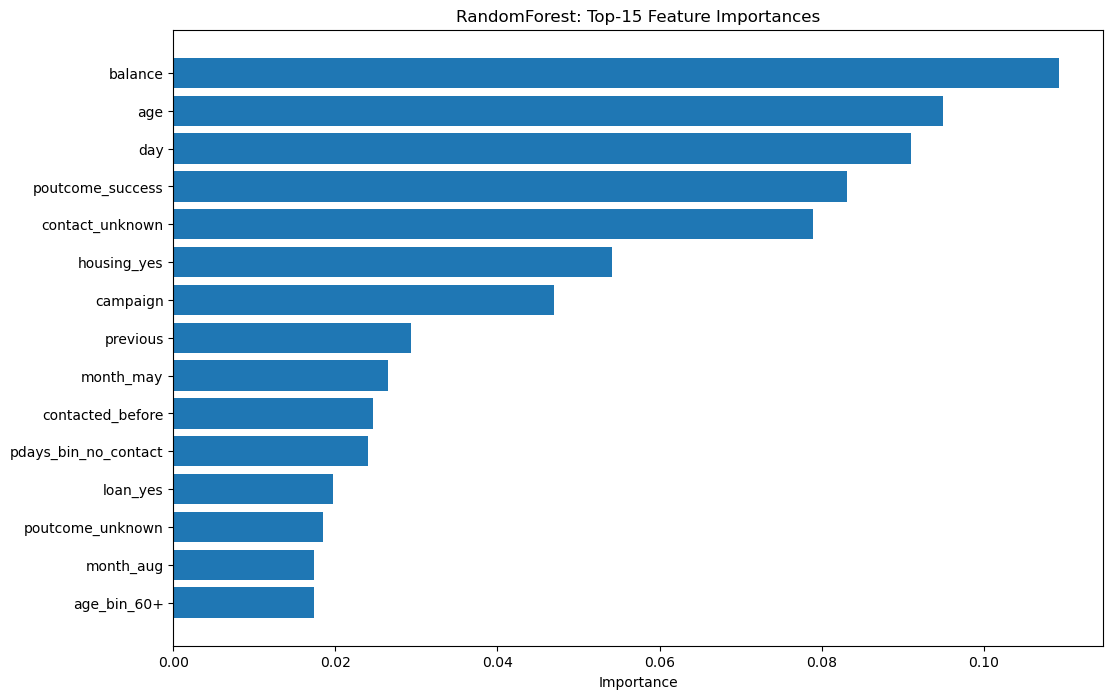

In [339]:
top = imp.head(15).iloc[::-1]  # переворачиваем, чтобы самый важный был сверху

plt.figure(figsize=(12,8))
plt.barh(top["feature"], top["importance"])
plt.xlabel("Importance")
plt.title("RandomForest: Top-15 Feature Importances")
plt.show()

##### После Feature Importance, можно видеть, что **самым сильным фактором предсказания является balance**, что говорит нам о нелинейной зависимости, так как логистическая регрессия его не выявила. Также нелинейная зависимость заметна в **age** и **day**.

**Надо проверить влияние balance**

In [340]:
df.groupby('deposit')['balance'].median()

deposit
no     414.0
yes    733.0
Name: balance, dtype: float64

**Действительно, медиана выше. Но надо проверить статистически. Так как распределение не нормальное используем Манна-Уитни**

In [341]:
from scipy.stats import mannwhitneyu

yes_balance = df[df['deposit'] == 'yes']['balance']
no_balance = df[df['deposit'] == 'no']['balance']

stat, p = mannwhitneyu(yes_balance, no_balance, alternative='two-sided')
p

np.float64(3.126411377149539e-62)

**Различие баланса между группами yes и no статистически значимо**

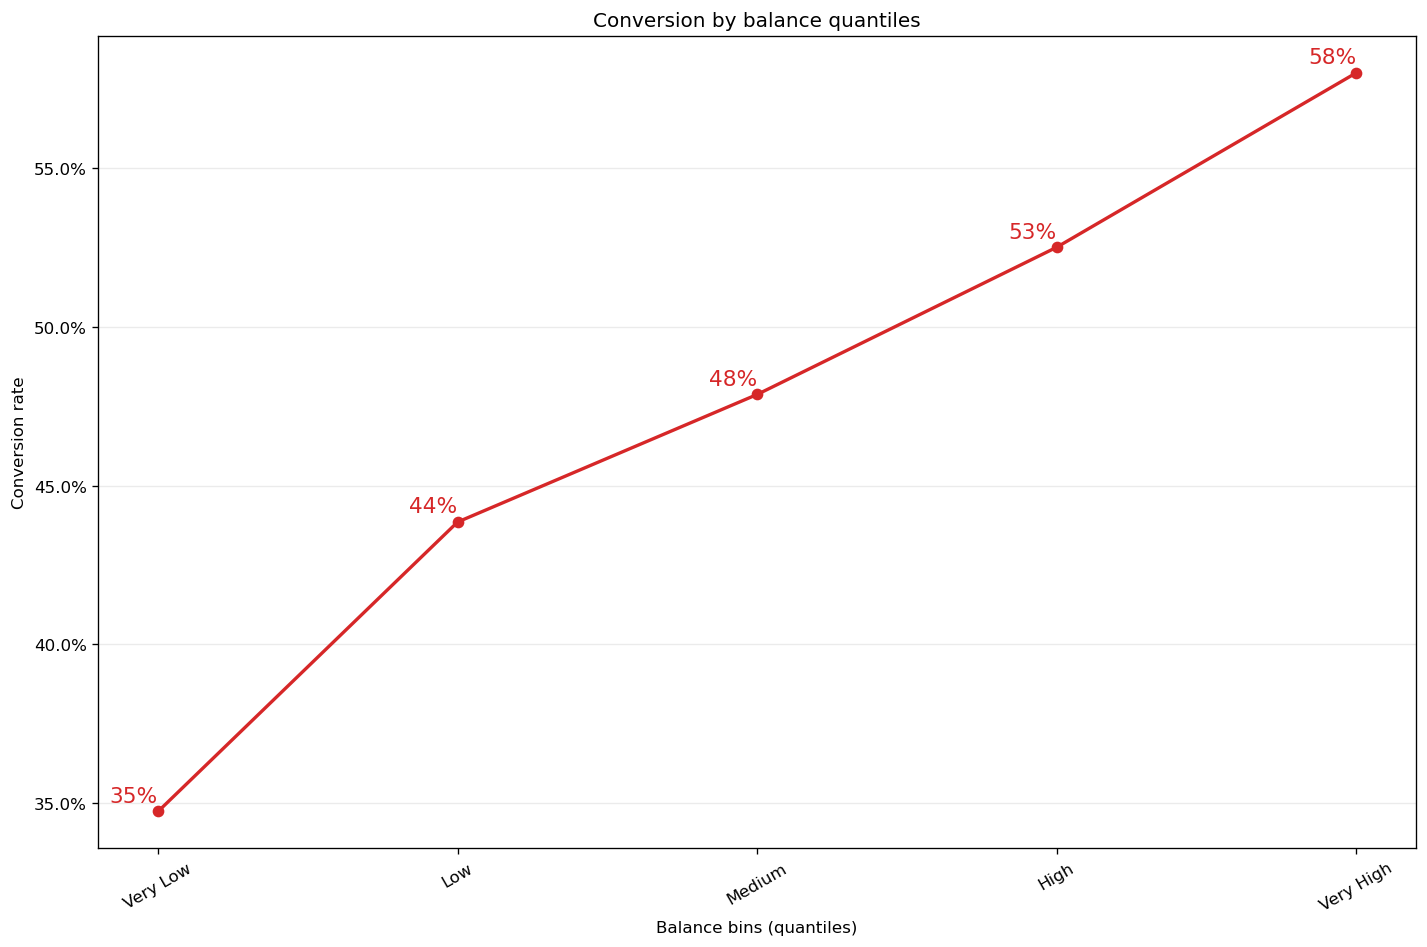

In [375]:
df['balance_bin'] = pd.qcut(df['balance'], q=5)

df['balance_bin'] = df['balance_bin'].cat.rename_categories(
    ['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

conv_balance = (
    df.groupby('balance_bin', observed=True)['deposit']
      .value_counts(normalize=True)
      .unstack()
      .get('yes')
      .reindex(['Very Low', 'Low', 'Medium', 'High', 'Very High'])
)

x = np.arange(len(conv_balance))

plt.figure(figsize=(12, 8), dpi=120)

plt.plot(x, conv_balance.values, marker='o', linewidth=2, color='tab:red')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(x, conv_balance.index.astype(str), rotation=30)

# подписи процентов
for xi, v in zip(x, conv_balance.values):
    plt.text(xi, v + 0.003, f"{v:.0%}", ha='right', color='tab:red', fontsize=13)

plt.title("Conversion by balance quantiles")
plt.ylabel("Conversion rate")
plt.xlabel("Balance bins (quantiles)")
plt.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [376]:
df['balance_bin_raw'] = pd.qcut(df['balance'], q=5)

# получаем интервалы
intervals = df['balance_bin_raw'].cat.categories

labels = df['balance_bin'].cat.categories

bin_table = pd.DataFrame({
    "Category": labels,
    "Lower bound": [interval.left for interval in intervals],
    "Upper bound": [interval.right for interval in intervals]
})

bin_table

,Category,Lower bound,Upper bound
0,Very Low,-6847.001,62.0
1,Low,62.000,337.0
2,Medium,337.000,862.6
3,High,862.600,2223.0
4,Very High,2223.000,81204.0


**График подтвержает влияние balance на открытие депозита**

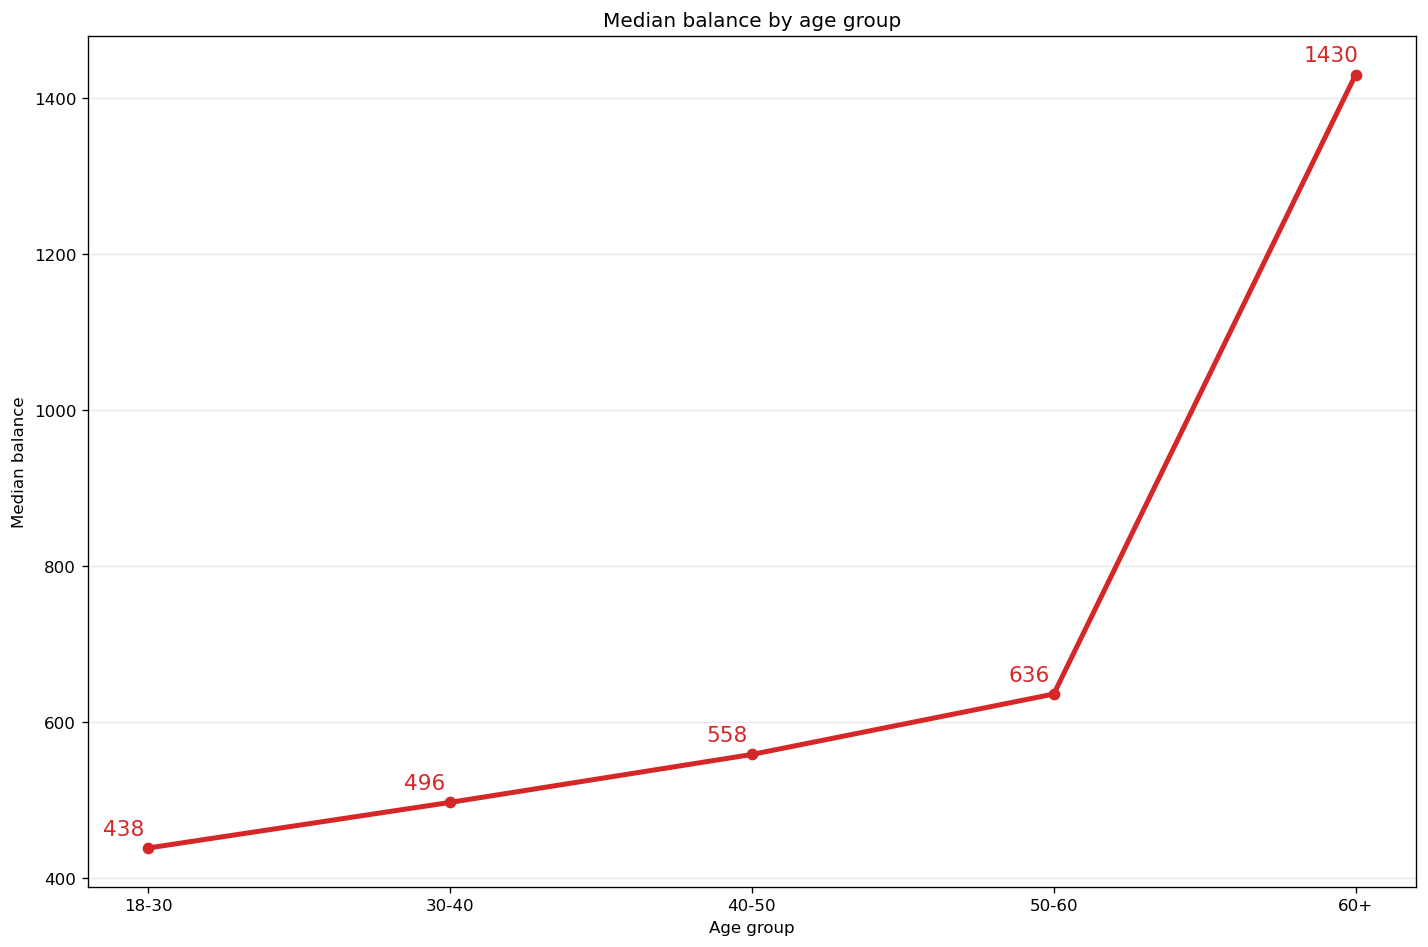

In [395]:
order = ['18-30', '30-40', '40-50', '50-60', '60+']

median_balance = (
    df.groupby('age_bin', observed=True)['balance']
      .median()
      .reindex(order)
)

x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(12, 8), dpi=120)

ax.plot(x, median_balance.values, marker='o', linewidth=3, color='tab:red')

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_xlabel('Age group')
ax.set_ylabel('Median balance')
ax.grid(axis='y', alpha=0.3)

# подписи значений (твой стиль)
for xi, v in zip(x, median_balance.values):
    ax.annotate(
        f'{v:.0f}',
        xy=(xi, v),
        xytext=(-15, 8),
        textcoords='offset points',
        ha='center',
        fontsize=13,
        color='tab:red'
    )

plt.title('Median balance by age group')
plt.tight_layout()
plt.show()

**Старшие клиенты обладают существенно более высоким медианным балансом, что вероятно объясняет их повышенную конверсию в депозитный продукт.**

**Если сравнить модели по profit, то можно увидеть, что RandomForest при пороге 0.3 оценил прибыль лучше чем логистика, 89617 и 87259 соответственно**
* Также ROC-AUC в форесте чуть выше, что говорит о более точном предсказании.

### Далее посмотрим коэффициенты регрессии, чтобы посмотреть направление влияния

In [344]:
lr_model = pipe.named_steps["lr"]

In [345]:
coefs = lr_model.coef_[0]
features = X_train.columns

In [396]:
coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": coefs
})

coef_table = coef_table.sort_values("coefficient", ascending=False)

print("\nСамые положительные:")
print(coef_table.head(15))
print("\nСамые отрицательные:")
print(coef_table.tail(15))


Самые положительные:
                 feature  coefficient
5       contacted_before     0.609338
39      poutcome_success     0.583478
44           age_bin_60+     0.284241
40      poutcome_unknown     0.257651
47  pdays_bin_no_contact     0.237353
33             month_mar     0.180985
20    education_tertiary     0.163978
36             month_oct     0.135121
28             month_dec     0.104912
1                balance     0.095172
13           job_student     0.081539
37             month_sep     0.079482
19   education_secondary     0.068645
32             month_jun     0.048741
38        poutcome_other     0.046121

Самые отрицательные:
              feature  coefficient
46     pdays_bin_300+    -0.101548
17    marital_married    -0.107260
41      age_bin_30-40    -0.113160
45  pdays_bin_100-300    -0.121221
29          month_feb    -0.135506
24           loan_yes    -0.146342
30          month_jan    -0.191672
23        housing_yes    -0.192563
0                 age    -0.19405

### Мы посмотрели на Feature Importance и коэффициенты регрессии, но основе этого можно сказать какие есть устойчивые факторы:
* **poutcome_success:**
  * В логистике +0.58
  * В форесте 0.083(топ-4)
  * Вывод: Прошлый успешный контакт один из ключевых факторов. Это и линейный эффект, и предсказательно важный признак
* **housing_yes:**
  * В логистике −0.19
  * В форесте 0.054 (топ-6)
  * Вывод: Наличие ипотечного кредита заметно снижает вероятность отклика. И при этом признак реально важен для предсказания
* **campaign:**
  * В логистике −0.21
  * В форесте 0.047
  * Вывод: Чем больше контактов в текущей кампании, тем хуже отклик
* **contact_unknown:**
  * В логистике −0.5
  * В форесте 0.078 (топ-5)
  * Вывод: Если тип контакта неизвестен — вероятность сильно ниже

### Сравнивая факторы у двух моделей можно выделить ключевые, при которых вероятность оформления срочного депозита будет максимальной
#### Это такие факторы как:
* **Уже контактировали ранее**
* **Был успешный прошлый контакт**
* **Возраст от 30-50 или страше 60**
* **Имеет высокий баланс**
* **Не имеет ипотеки**
* **Не имеет кредита**
* **Контакт не “unknown”**